In [1]:
select='BC'

In [2]:
required_args = {
    "config_file_path": 'config/test_config.yml',
    "province_short_code": f'{select}',
    "resource_type": 'solar'
}
store=f"data/store/solar_resources_{required_args['province_short_code']}.h5"
from linkingtool.hdf5_handler import DataHandler

datahandler=DataHandler(store)

In [3]:
# datahandler.from_store('cells')

In [4]:
# from linkingtool.AttributesParser import AttributesParser
# from linkingtool.boundaries import GADMBoundaries
# from linkingtool.coders import CODERSData
# from linkingtool.era5_cutout import ERA5Cutout
# from linkingtool.lands import LandContainer
# from linkingtool.CellCapacityProcessor import CellCapacityProcessor
# cell_processor=CellCapacityProcessor(**required_args)
# from linkingtool.timeseries import Timeseries
# ts=Timeseries(**required_args)

from linkingtool import visuals as vis
from workflow.scripts.solar_module_v2 import SolarResources
solar=SolarResources(**required_args)


In [5]:
wcss_tolr=0.05
data6=solar.get_clusters(wcss_tolr)

/local-scratch/localhome/mei3/eliasinul/repositories/Linking_tool/linkingtool/hdf5_handler.py:47: UserWarning: Geometry column does not contain geometry.
  self.data['geometry'] = self.data['geometry'].apply(dumps)
2024-10-15 11:16:56,307 - INFO - Data (GeoDataFrame) saved to data/store/solar_resources_BC.h5 with key 'cells'


>> Calculating Score for each Cell...
>> Estimating optimal number of Clusters for each region based on the Score for each Cell ...
Zone Stikine - Optimal k for p_lcoe based clustering: 4

>> Estimating optimal number of Clusters for each region based on the Score for each Cell ...
Zone Skeena-QueenCharlotte - Optimal k for p_lcoe based clustering: 3

>> Estimating optimal number of Clusters for each region based on the Score for each Cell ...
Zone NorthernRockies - Optimal k for p_lcoe based clustering: 4

>> Estimating optimal number of Clusters for each region based on the Score for each Cell ...
Zone Kitimat-Stikine - Optimal k for p_lcoe based clustering: 5

>> Estimating optimal number of Clusters for each region based on the Score for each Cell ...
Zone PeaceRiver - Optimal k for p_lcoe based clustering: 4

>> Estimating optimal number of Clusters for each region based on the Score for each Cell ...
Zone Cariboo - Optimal k for p_lcoe based clustering: 4

>> Estimating optimal n

/local-scratch/localhome/mei3/eliasinul/repositories/Linking_tool/linkingtool/cluster.py:145: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  region_optimal_k_df['Optimal_k'].fillna(0, inplace=True)
2024-10-15 11:17:00,374 - INFO -  Preparing Clusters...
2024-10-15 11:17:00,374 - INFO -  Creating cluster for Stikine 1/28
2024-10-15 11:17:00,392 - INFO -  Creating cluster for Skeena-QueenCharlotte 2/28
2024-10-15 11:17:00,461 - INFO -  Creating cluster for NorthernRockies 3/28
2024-10-15 11:17:00,475 - INFO -  Creating cluster fo

Zone GreaterVancouver - Optimal k for p_lcoe based clustering: 3

>>> K-means clustering Elbow plots generated for each region based on the Score for each Cell ...
Optimal-k based on 'lcoe' clustering calculated for 28 zones and saved to cell dataframe.

>>> Mapping the Optimal Number of Clusters for Each region ...


2024-10-15 11:17:00,536 - INFO -  Creating cluster for PeaceRiver 5/28
2024-10-15 11:17:00,554 - INFO -  Creating cluster for Cariboo 6/28
2024-10-15 11:17:00,571 - INFO -  Creating cluster for CentralCoast 7/28
2024-10-15 11:17:00,612 - INFO -  Creating cluster for MountWaddington 8/28
2024-10-15 11:17:00,657 - INFO -  Creating cluster for Bulkley-Nechako 9/28
2024-10-15 11:17:00,675 - INFO -  Creating cluster for Comox-Strathcona 10/28
2024-10-15 11:17:00,713 - INFO -  Creating cluster for Fraser-FortGeorge 11/28
2024-10-15 11:17:00,732 - INFO -  Creating cluster for Thompson-Nicola 12/28
2024-10-15 11:17:00,749 - INFO -  Creating cluster for Columbia-Shuswap 13/28
2024-10-15 11:17:00,767 - INFO -  Creating cluster for CowichanValley 14/28
2024-10-15 11:17:00,784 - INFO -  Creating cluster for EastKootenay 15/28
2024-10-15 11:17:00,802 - INFO -  Creating cluster for PowellRiver 16/28
2024-10-15 11:17:00,820 - INFO -  Creating cluster for CentralKootenay 17/28
2024-10-15 11:17:00,838 

In [6]:
cells=datahandler.from_store('cells')
lcoe_threshold=20 

# Load clusters
clusters = solar.solar_clusters_nt.clusters

# Filter clusters based on LCOE
mask = clusters['lcoe'] <= lcoe_threshold
filtered_clusters = clusters[mask]

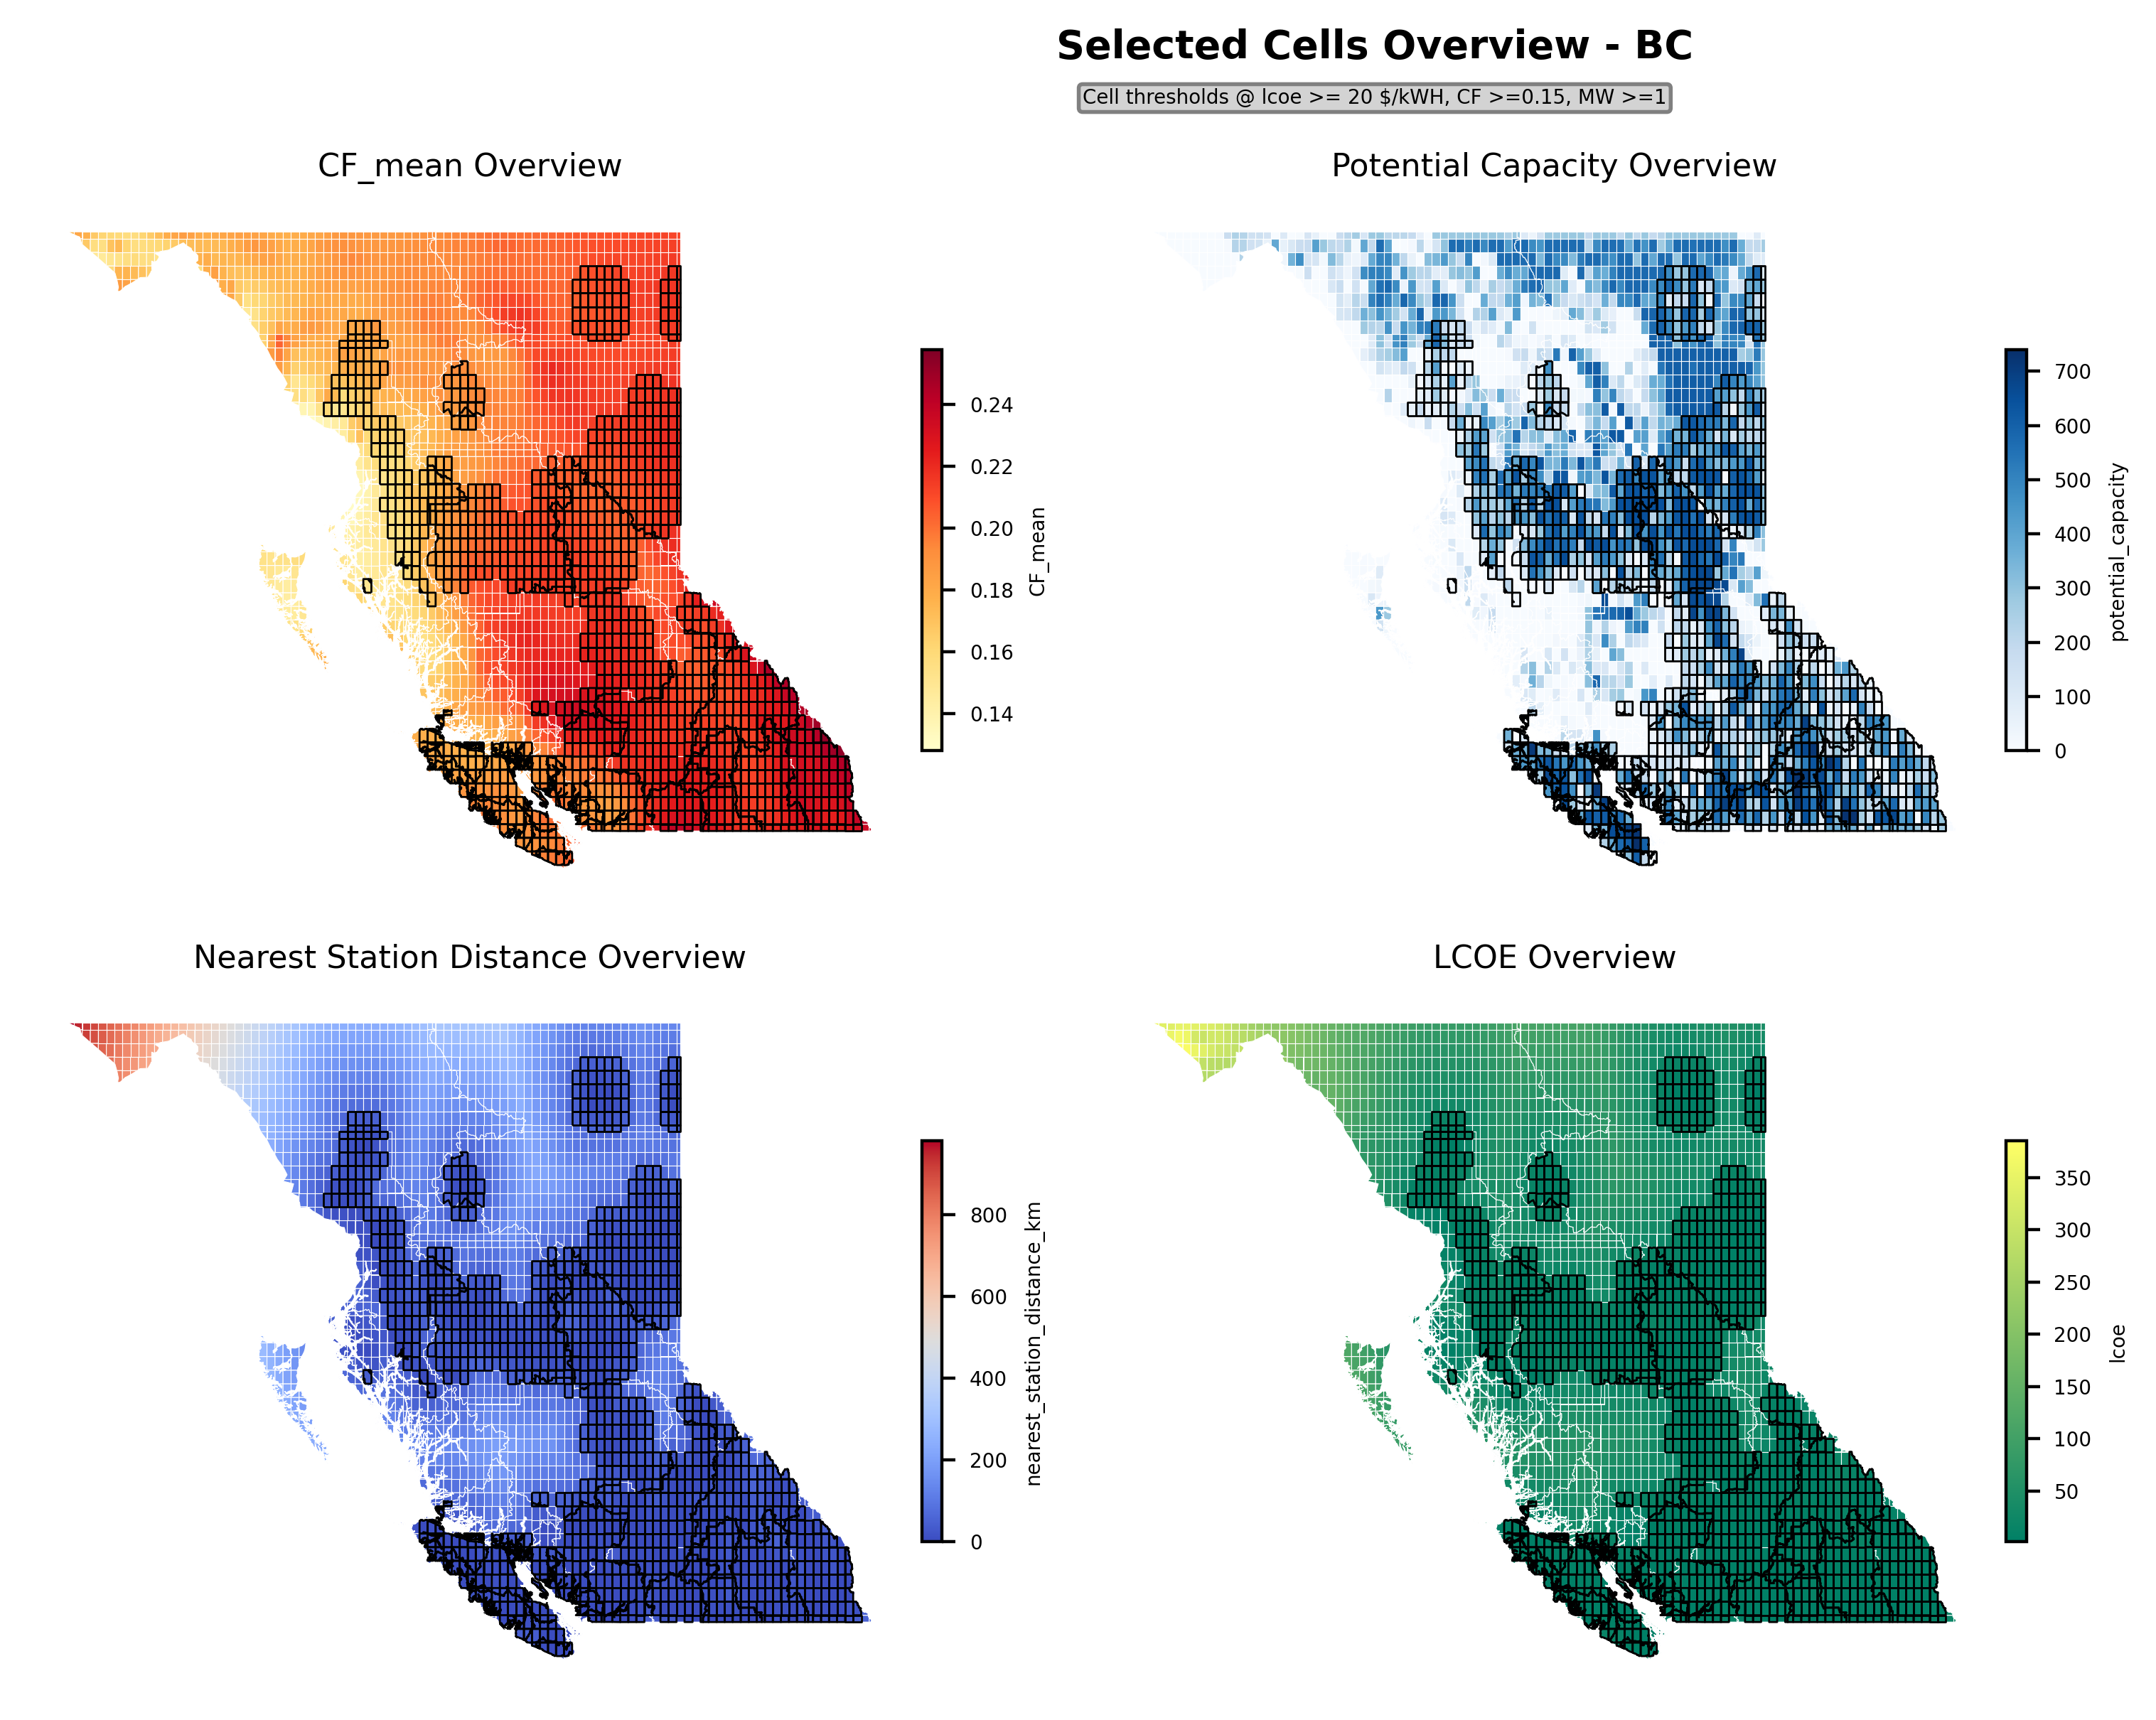

In [7]:
# data1=solar.get_CF_timeseries()
# data2=solar.get_cell_capacity()
# data3=solar.find_grid_nodes()
# data5=solar.score_cells()
# data=datahandler.from_store('cells') 
vis.get_selected_vs_missed_visuals(cells, 
                              required_args['province_short_code'],
                              lcoe_threshold=lcoe_threshold, 
                              CF_threshold=0.15, 
                              capacity_threshold=1,
                              text_box_x=.65,
                              text_box_y=.965,
                              title_x=.65,
                              title_y=1,
                              font_size=8,
                              dpi=400,
                              figsize=(8,6),
                              save=True
                              )

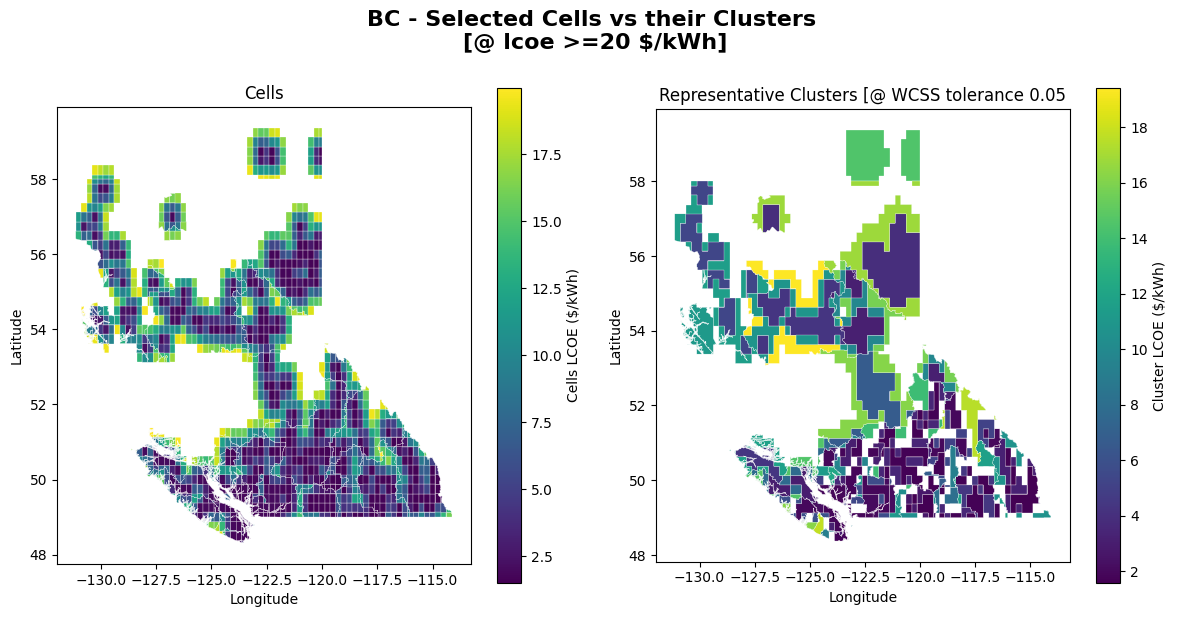

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Define the LCOE threshold
lcoe_threshold = 20  # You can set this to the appropriate value as needed

# Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot the selected cells on the left
cells[cells['lcoe'] <= lcoe_threshold].plot(
    column='lcoe',
    ax=ax[0],
    edgecolor='white',
    linewidth=0.2,
    legend=True,
    legend_kwds={'label': "Cells LCOE ($/kWh)", 'orientation': "vertical"}
)
ax[0].set_title('Cells')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')

# Plot the filtered clusters on the right
filtered_clusters.plot(
    column='lcoe',
    ax=ax[1],
    edgecolor='white',
    linewidth=0.2,
    legend=True,
    legend_kwds={'label': "Cluster LCOE ($/kWh)", 'orientation': "vertical"}
)
ax[1].set_title(f'Representative Clusters [@ WCSS tolerance {wcss_tolr}')
ax[1].set_xlabel('Longitude')
ax[1].set_ylabel('Latitude')

# Set a common title for the entire figure
fig.suptitle(f"{select} - Selected Cells vs their Clusters \n[@ lcoe >={lcoe_threshold} $/kWh]", fontsize=16, fontweight='bold')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjusts the top space to make room for the main title
plt.savefig(f'vis/Solar/cells vs cluster_ALL REGIONS_{select}')
# Show the plots
plt.show()


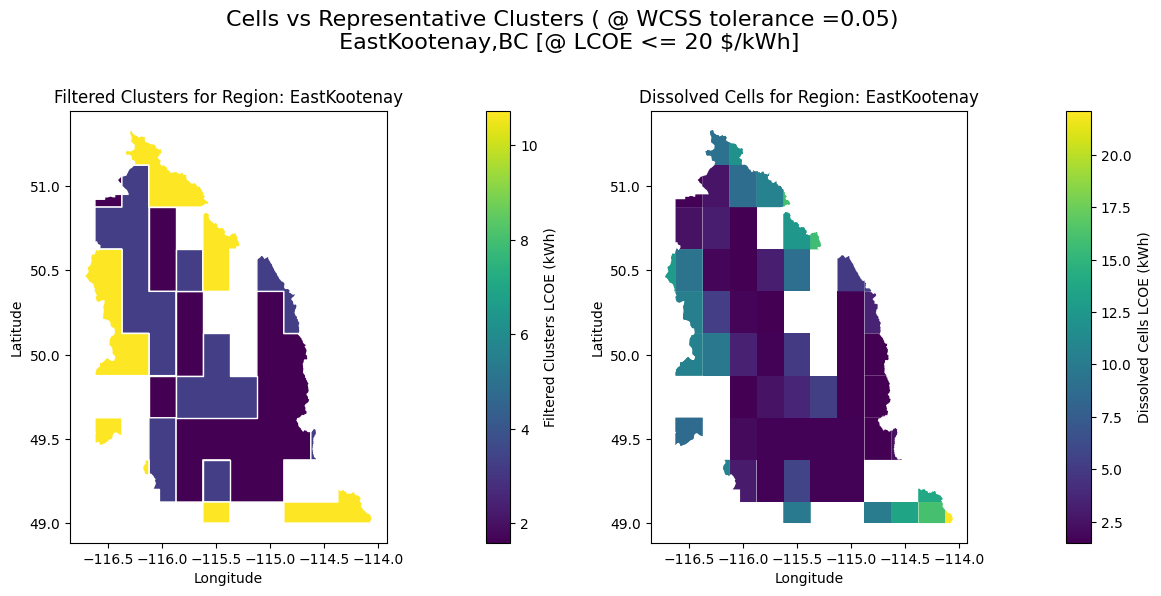

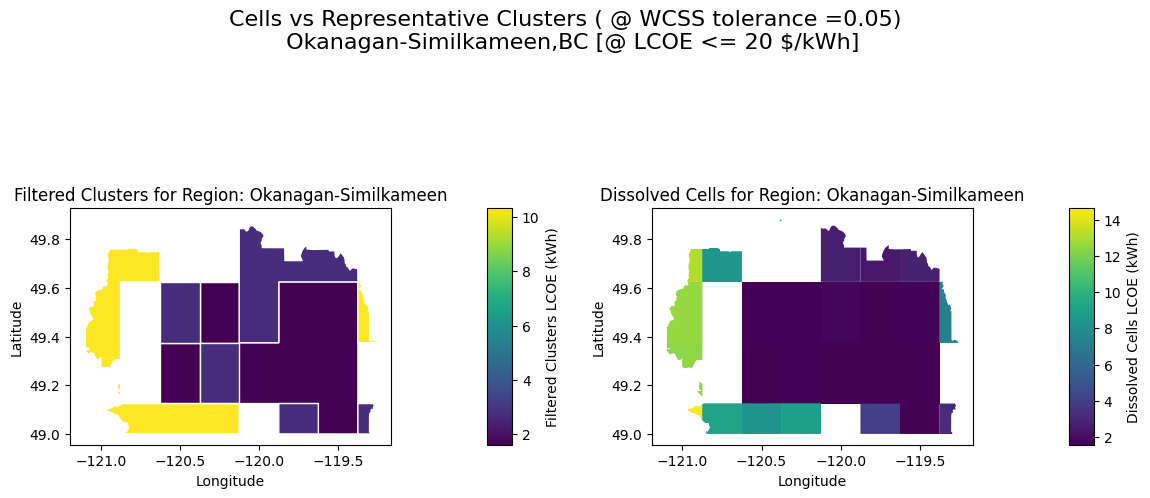

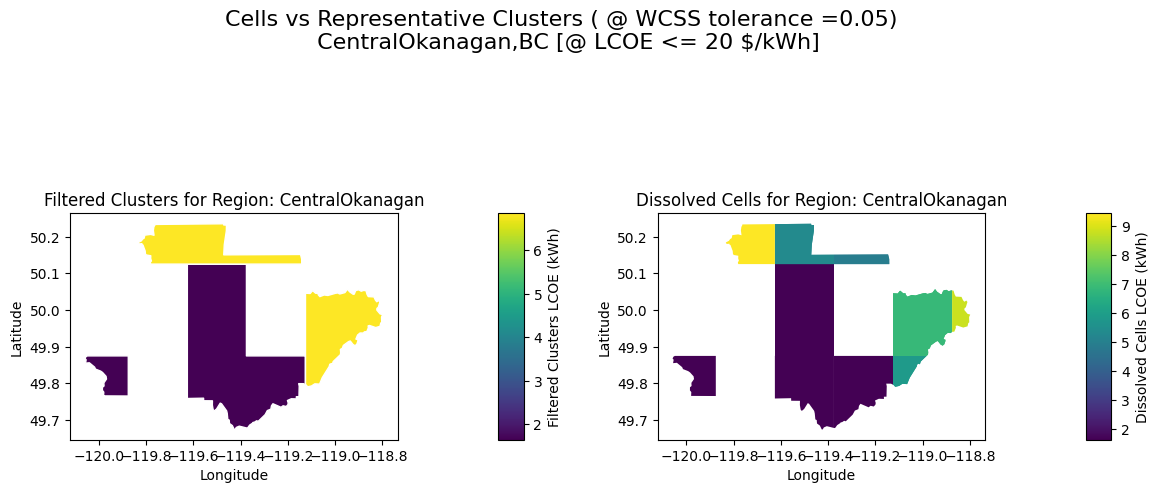

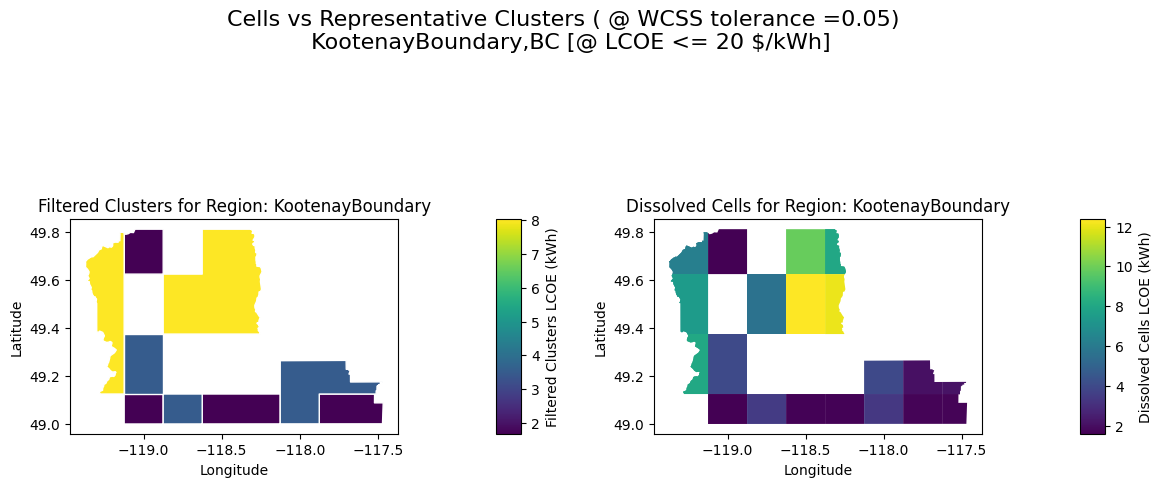

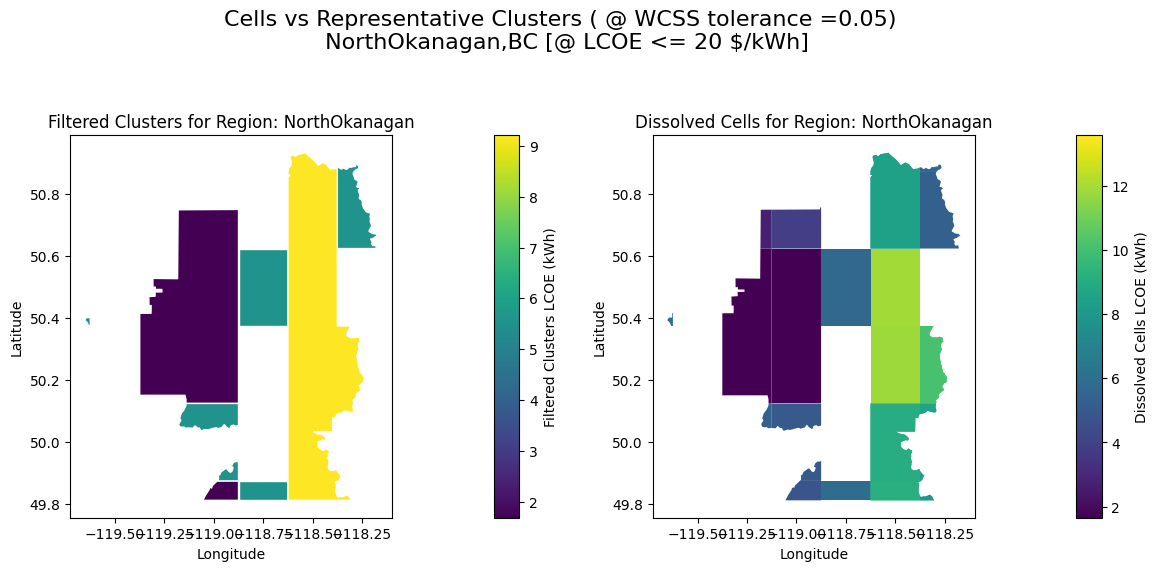

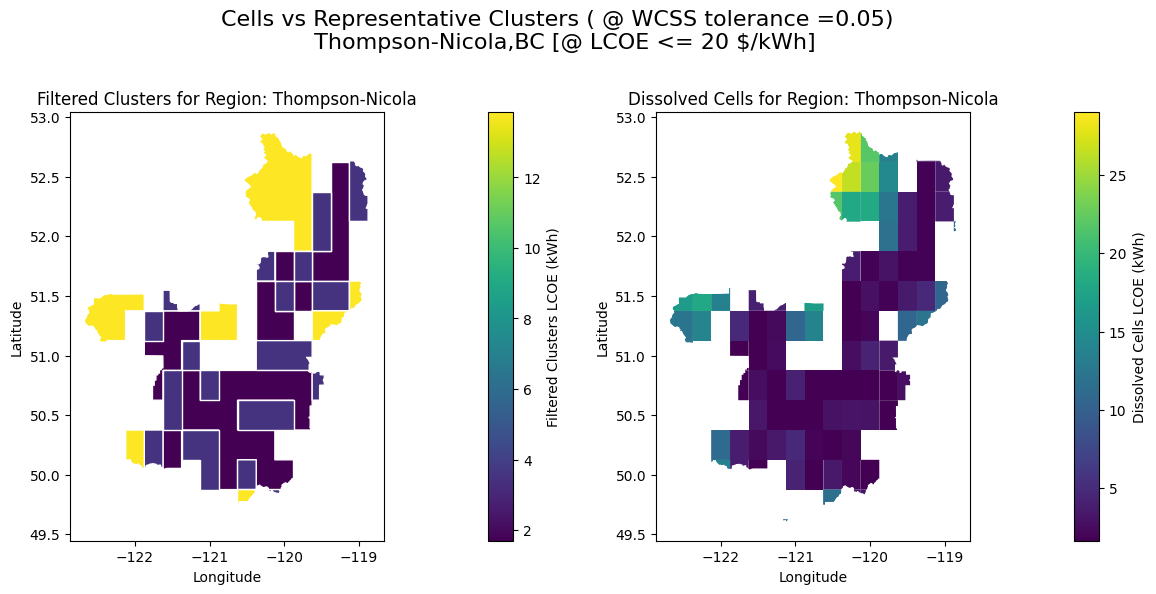

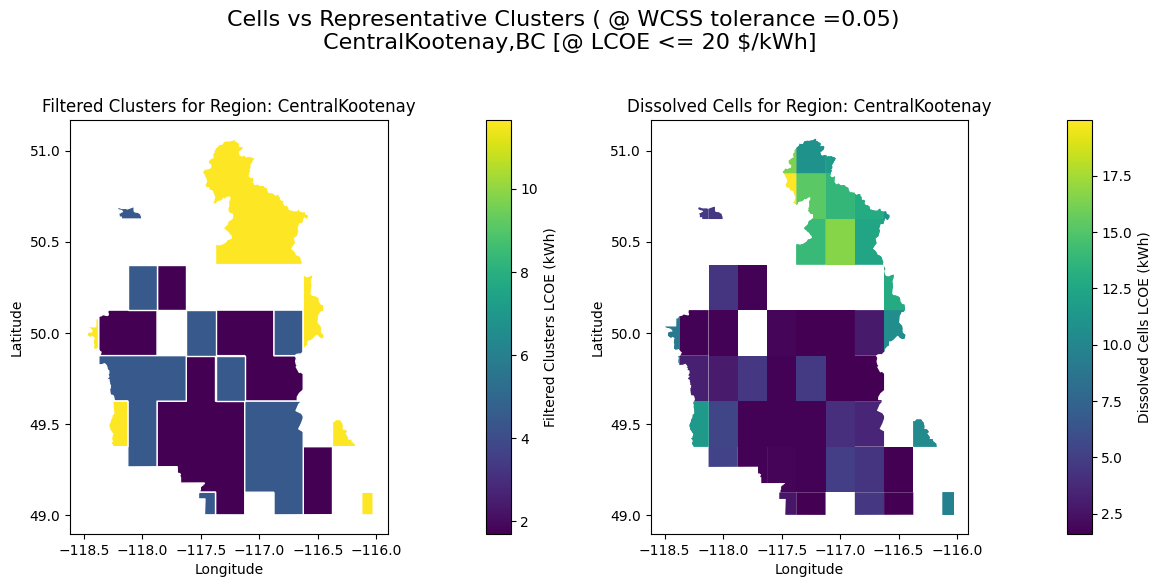

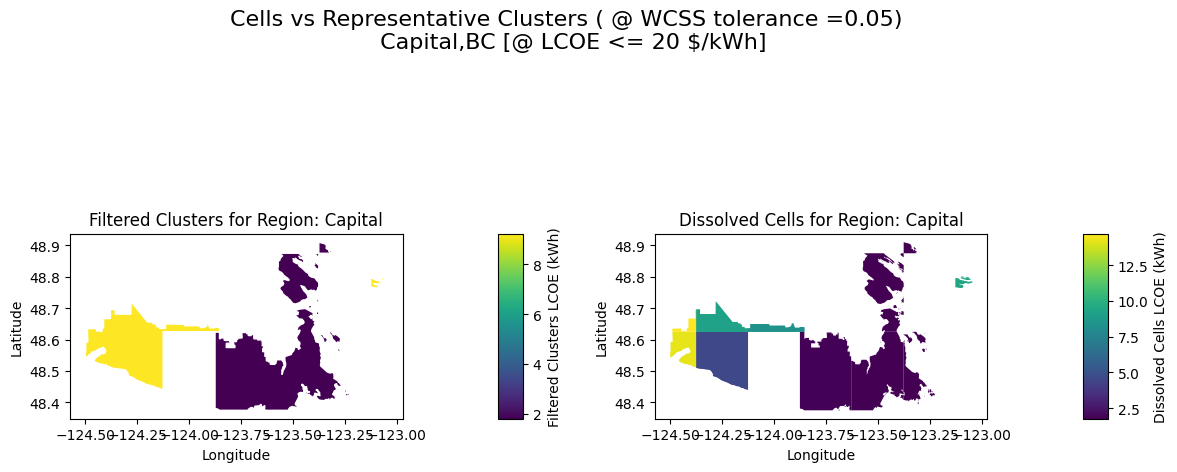

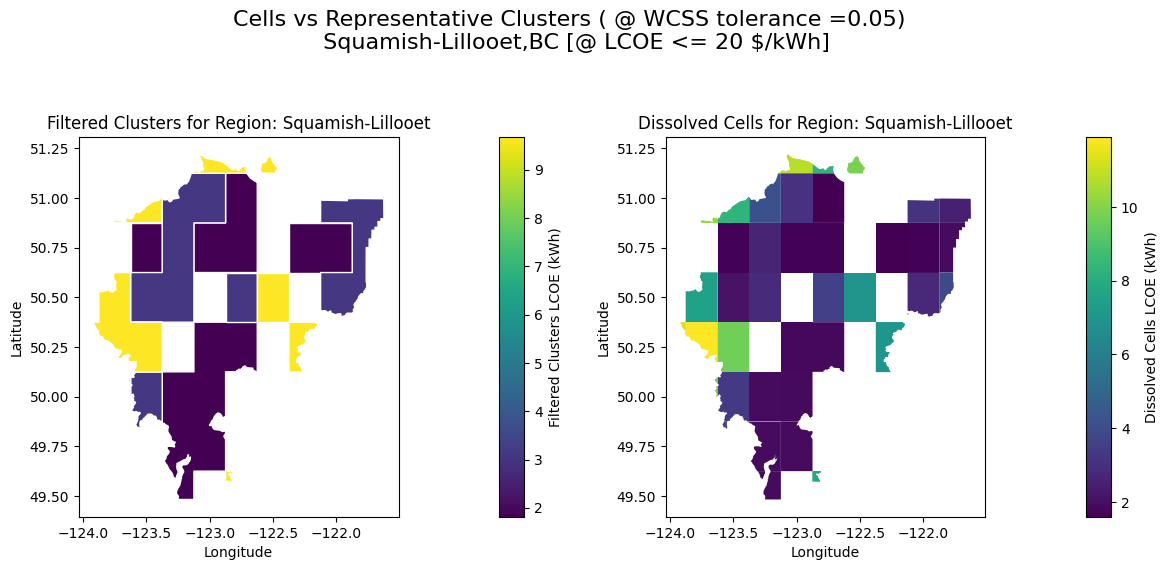

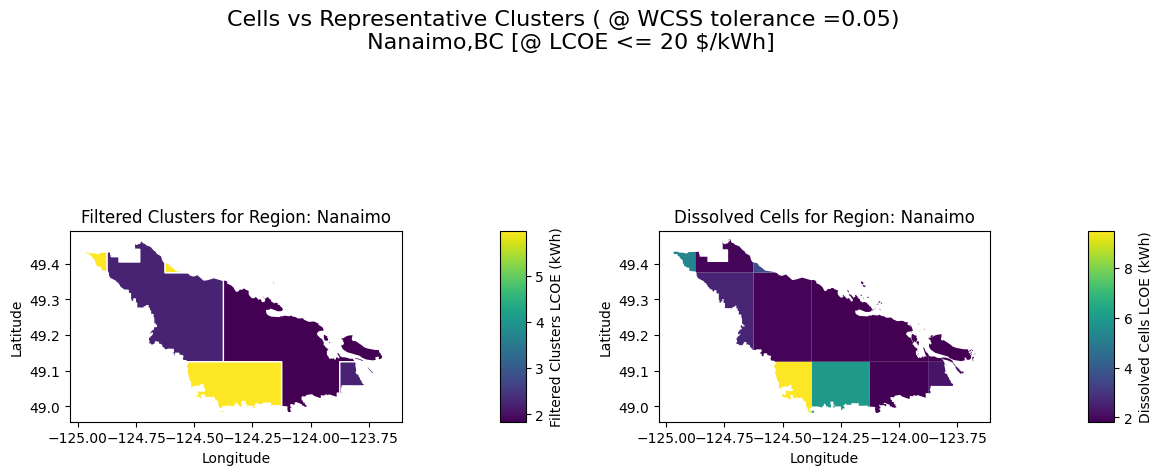

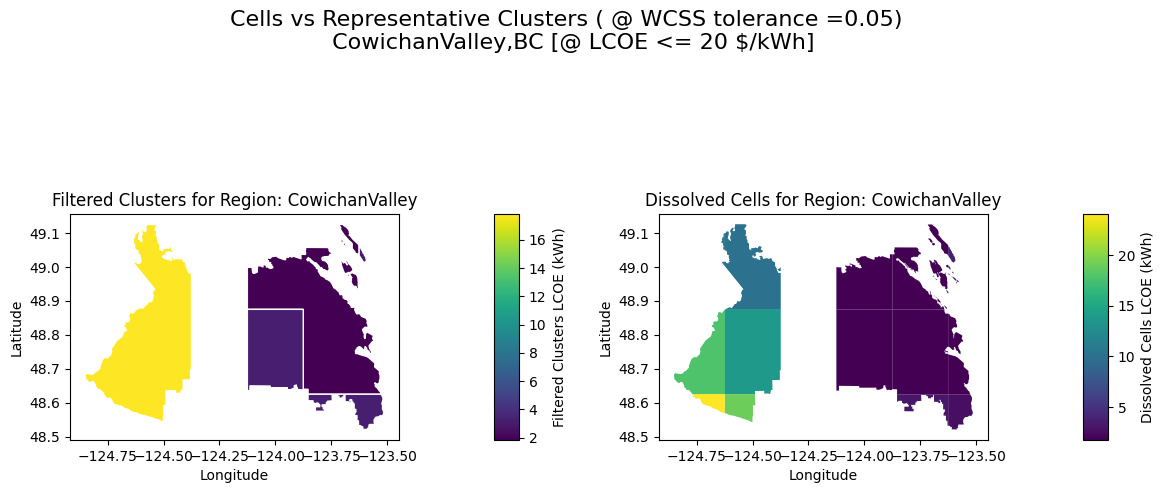

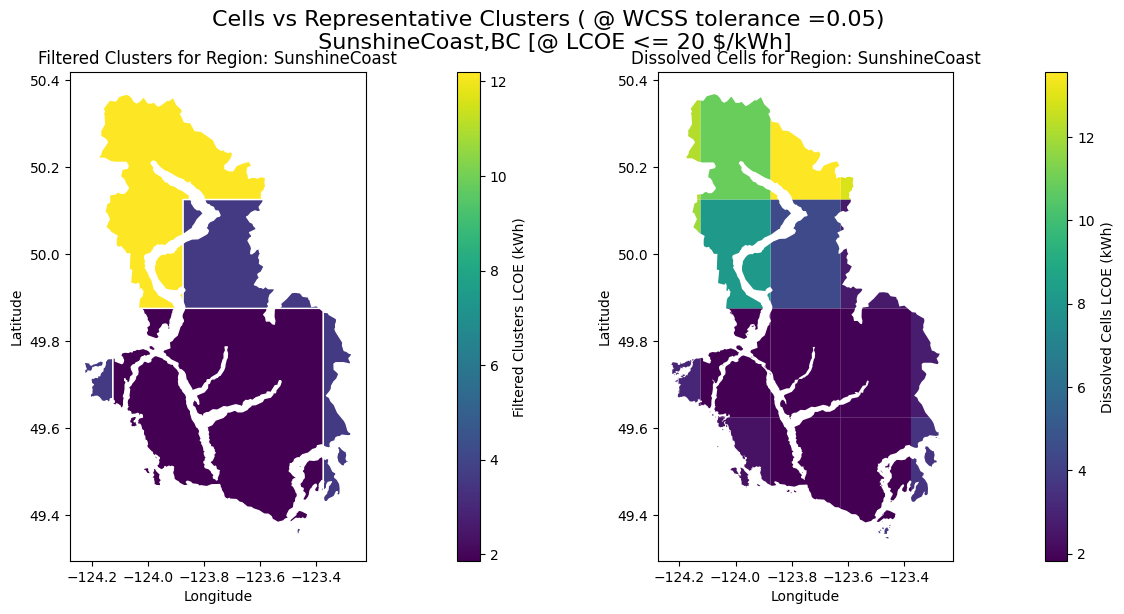

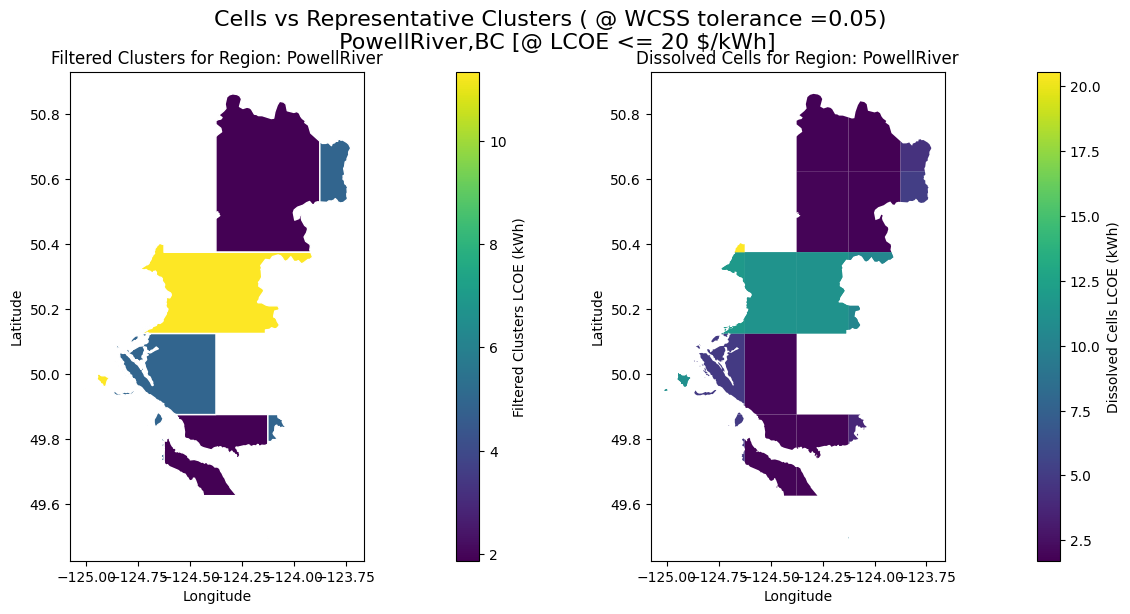

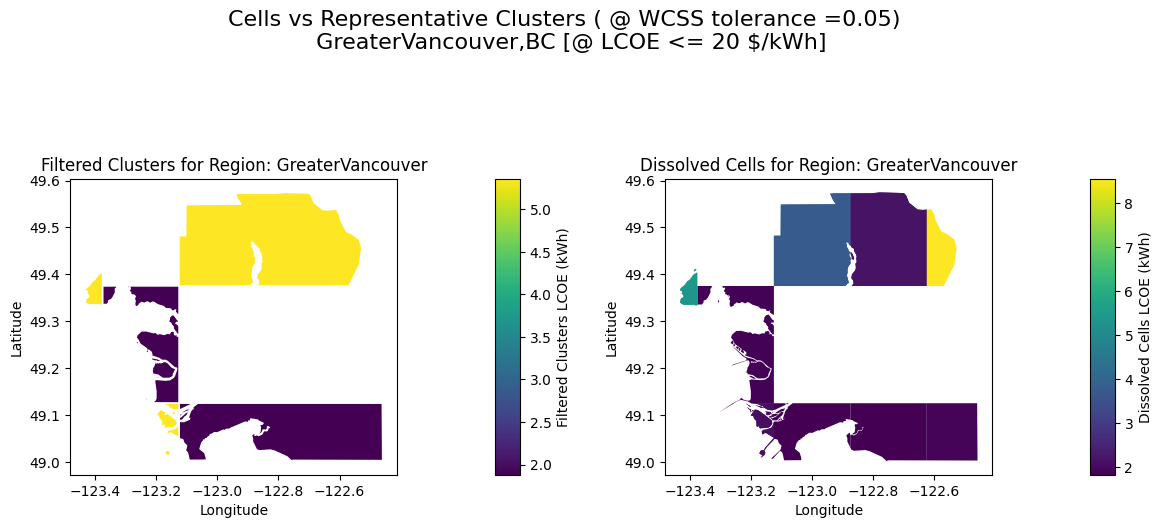

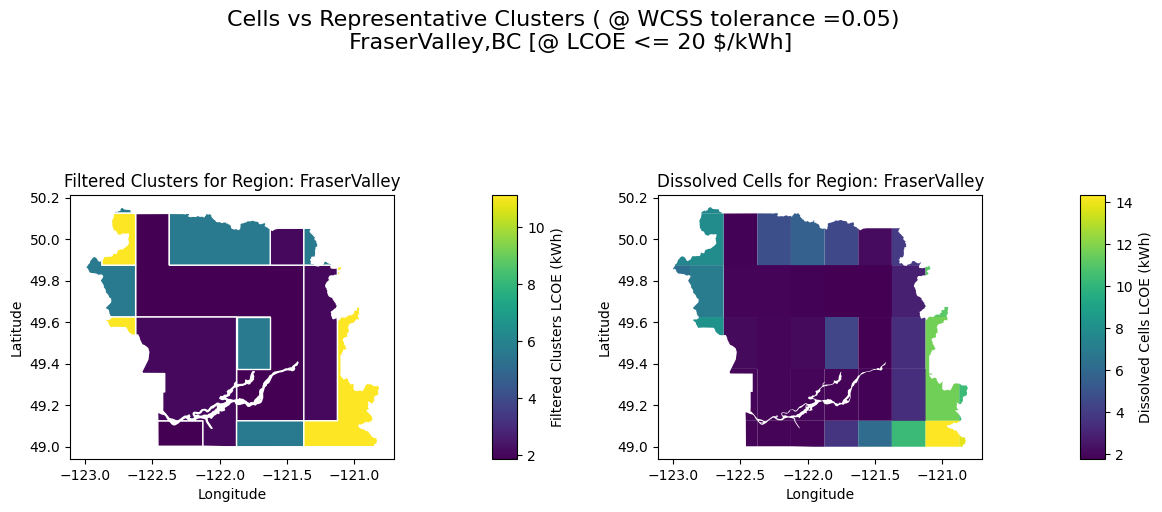

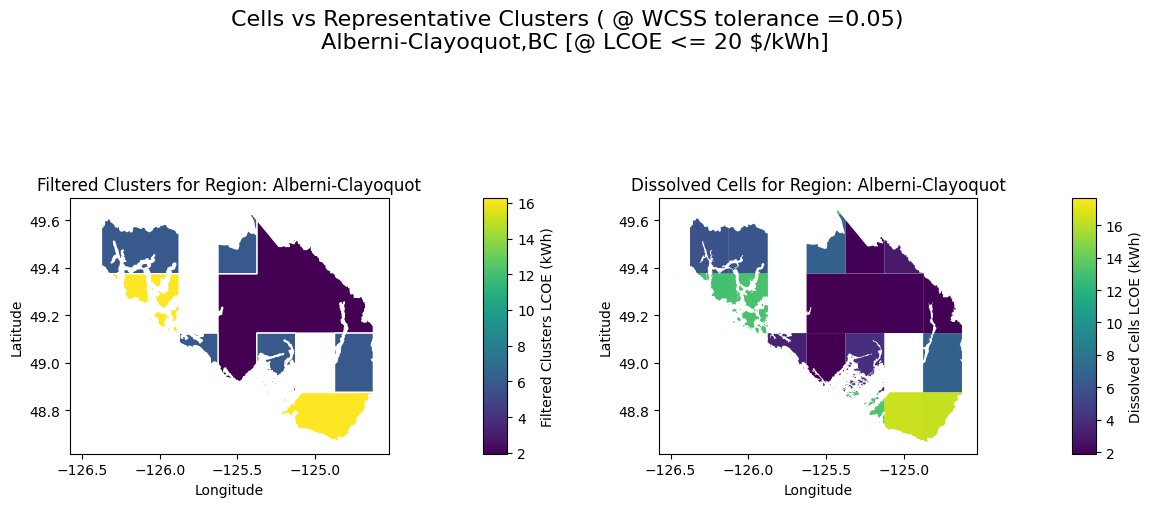

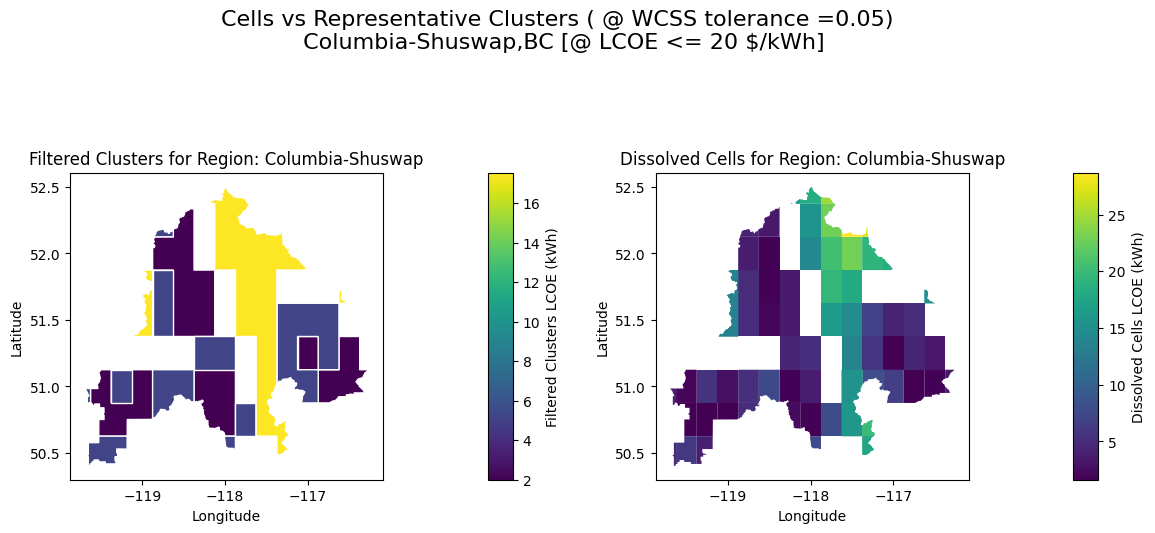

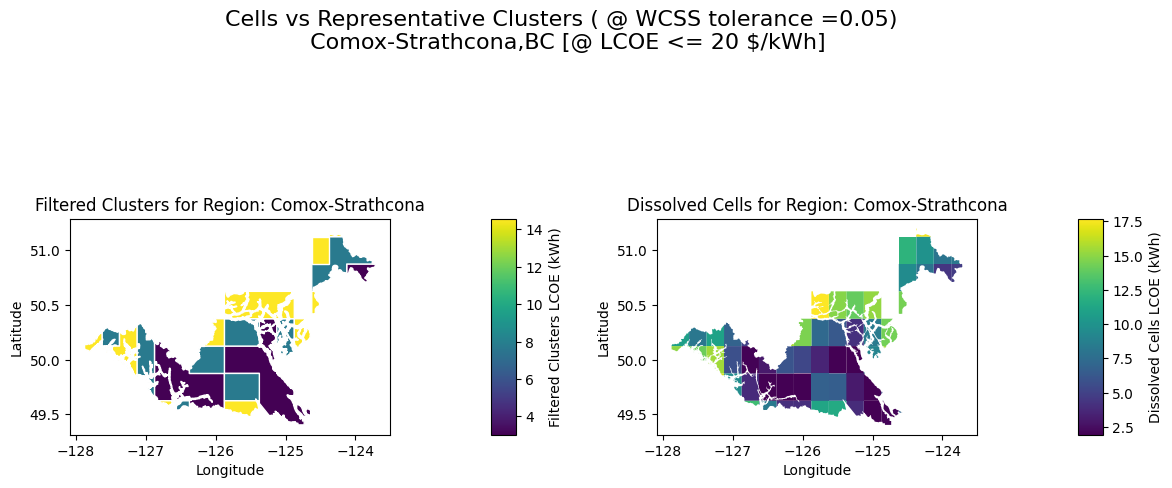

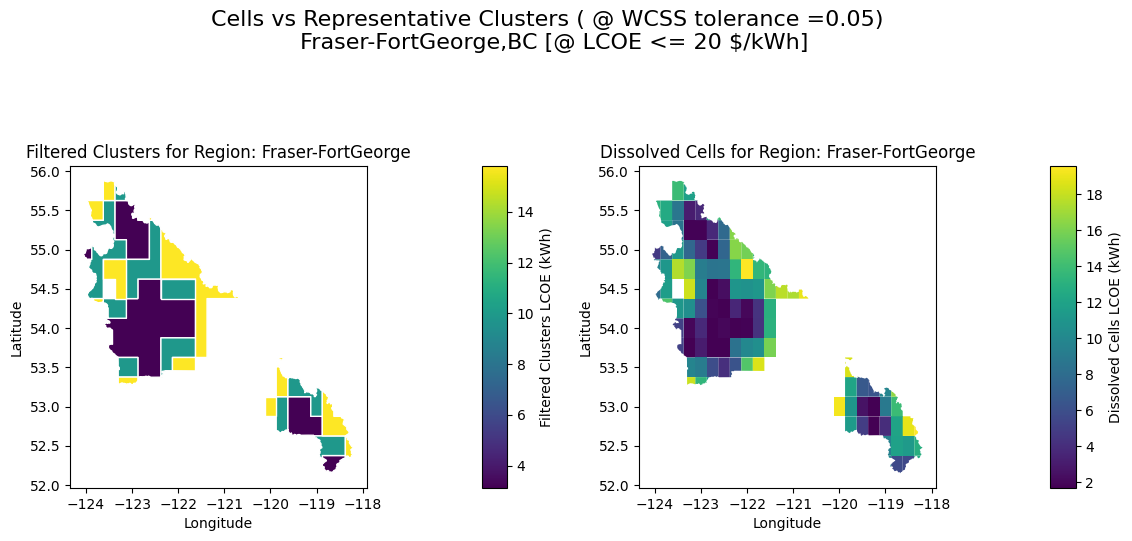

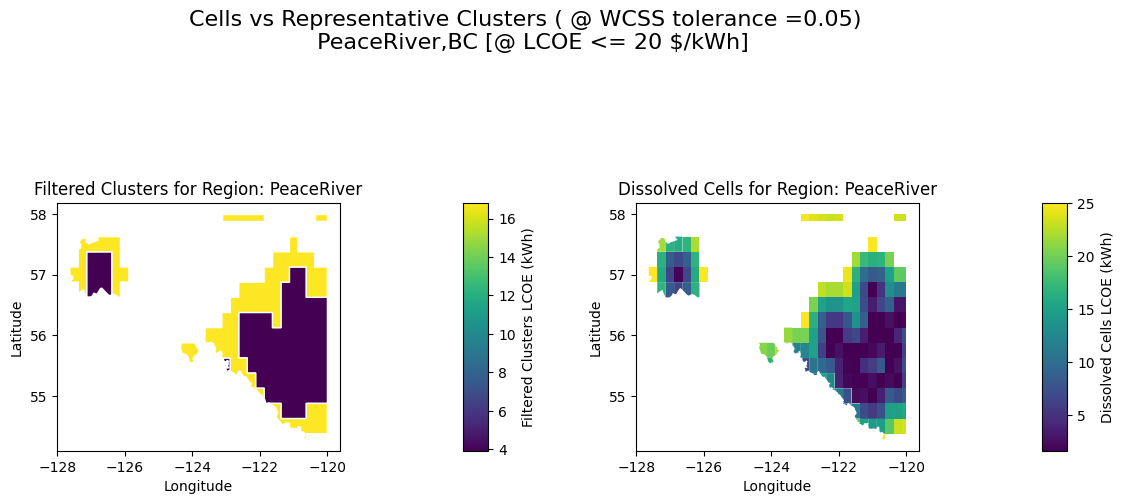

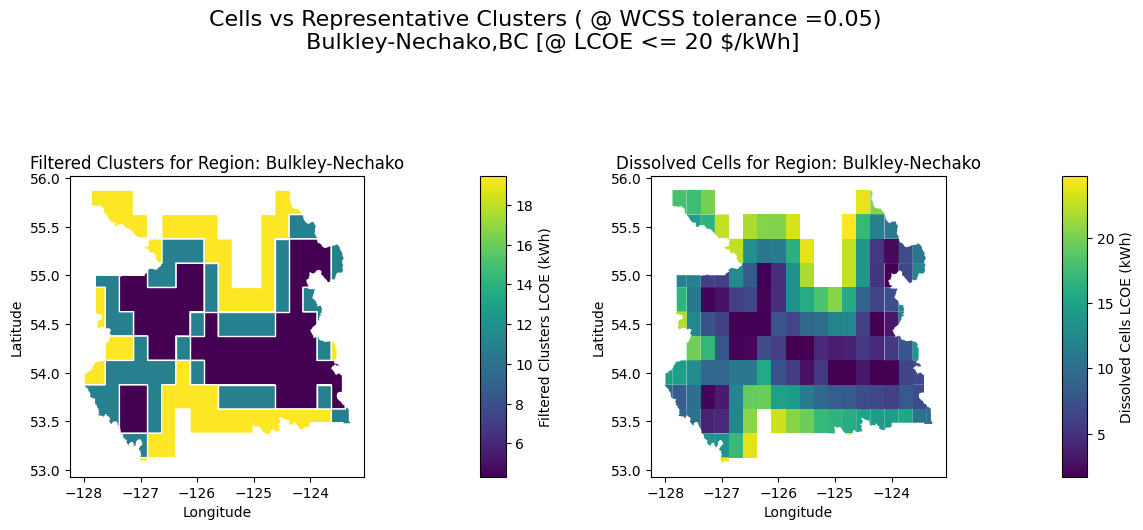

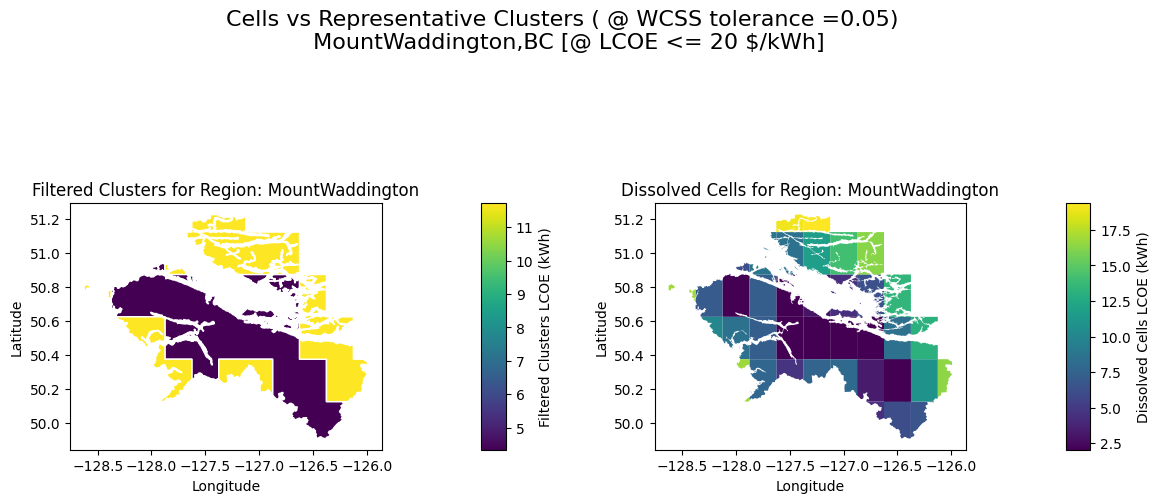

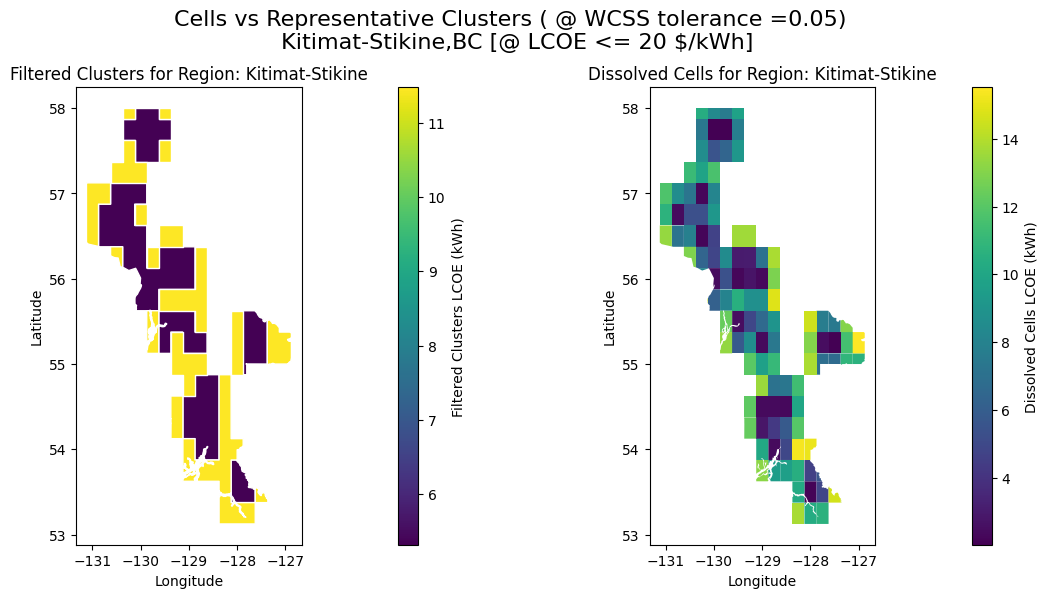

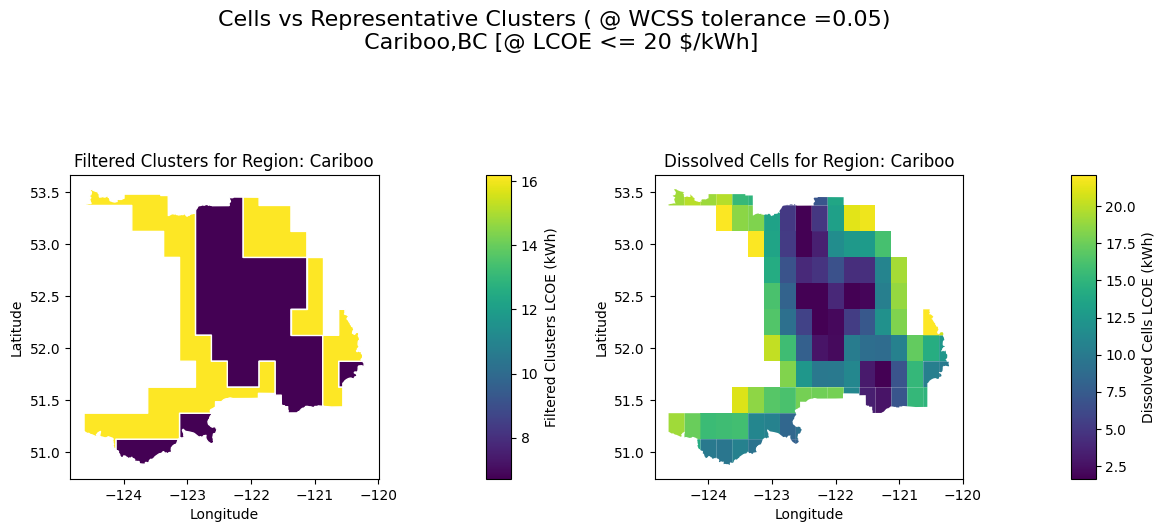

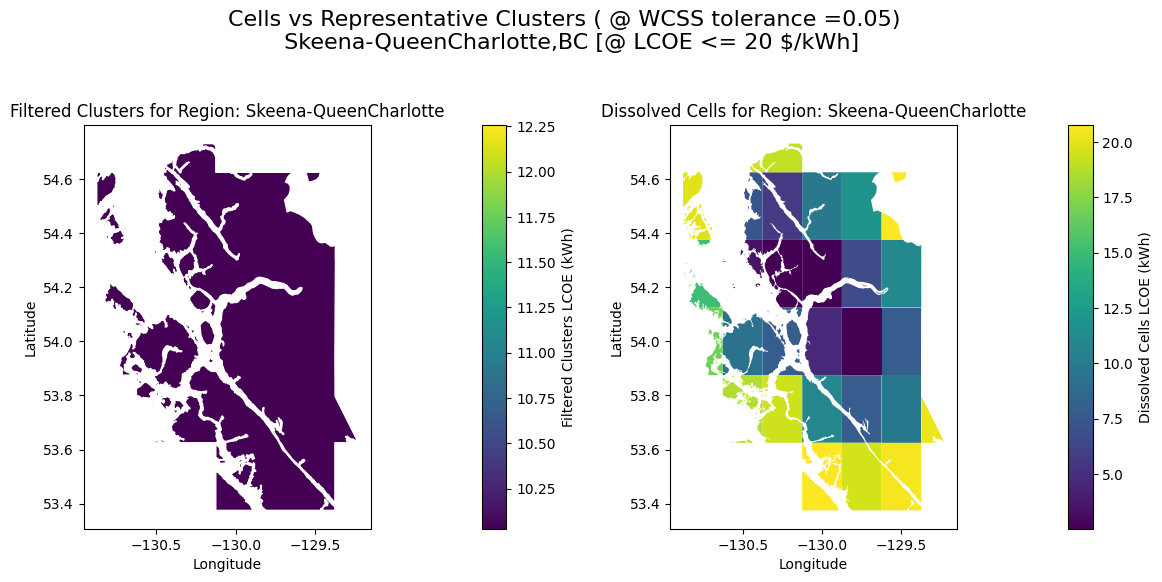

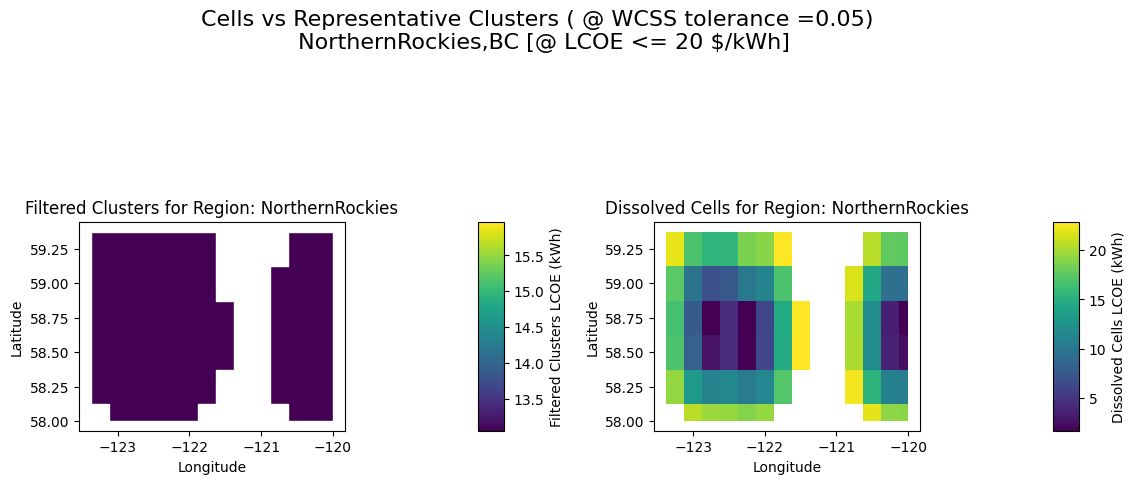

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Get unique regions from the filtered clusters
unique_regions = filtered_clusters['Region'].unique()

# Loop through each unique region and create plots
for region in unique_regions:
    # Filter clusters and cells based on the current region
    region_filtered_clusters = filtered_clusters[filtered_clusters['Region'] == region]

    # Prepare a list to collect all dissolved cell indices for the region
    dissolved_cell_indices = []

    # Collect dissolved indices for the current region
    for _, row in region_filtered_clusters.iterrows():
        dissolved_cell_indices.extend(list(solar.solar_clusters_nt.dissolved_indices[row.Region][row.Cluster_No]))

    # Extract the dissolved cells based on the collected indices
    dissolved_cells_region = cells.loc[dissolved_cell_indices]

    # Create a figure with 1 row and 2 columns
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Plot all filtered clusters for the current region on the left
    cmap_left = "viridis"  # Specify your desired colormap here
    region_filtered_clusters.plot(
        column='lcoe',
        edgecolor='white',
        ax=ax[0],
        cmap=cmap_left,  # Use the specified colormap
        legend=False  # Disable the default legend
    )

    # Create a divider for the left plot to add colorbar
    divider_left = make_axes_locatable(ax[0])
    cax_left = divider_left.append_axes("right", size="5%", pad=0.1)  # Adjust size and padding as needed

    # Create a colorbar
    sm_left = plt.cm.ScalarMappable(cmap=cmap_left, norm=plt.Normalize(vmin=region_filtered_clusters['lcoe'].min(), vmax=region_filtered_clusters['lcoe'].max()))
    sm_left.set_array([])
    cbar_left = fig.colorbar(sm_left, cax=cax_left)
    cbar_left.set_label("Filtered Clusters LCOE (kWh)")

    ax[0].set_title(f'Filtered Clusters for Region: {region}')
    ax[0].set_xlabel('Longitude')
    ax[0].set_ylabel('Latitude')

    # Plot all dissolved cells for the current region on the right
    cmap_right = "viridis"  # Specify your desired colormap here
    dissolved_cells_region.plot(
        column='lcoe',
        edgecolor='None',
        ax=ax[1],
        alpha=1,  # Adjust transparency for better visualization
        cmap=cmap_right,  # Use the specified colormap
        legend=False  # Disable the default legend
    )

    # Create a divider for the right plot to add colorbar
    divider_right = make_axes_locatable(ax[1])
    cax_right = divider_right.append_axes("right", size="5%", pad=0.1)  # Adjust size and padding as needed

    # Create a colorbar
    sm_right = plt.cm.ScalarMappable(cmap=cmap_right, norm=plt.Normalize(vmin=dissolved_cells_region['lcoe'].min(), vmax=dissolved_cells_region['lcoe'].max()))
    sm_right.set_array([])
    cbar_right = fig.colorbar(sm_right, cax=cax_right)
    cbar_right.set_label("Dissolved Cells LCOE (kWh)")

    ax[1].set_title(f'Dissolved Cells for Region: {region}')
    ax[1].set_xlabel('Longitude')
    ax[1].set_ylabel('Latitude')

    # Set a common title for the figure
    fig.suptitle(f"Cells vs Representative Clusters ( @ WCSS tolerance ={wcss_tolr}) \n {region},{select} [@ LCOE <= {lcoe_threshold} $/kWh]", fontsize=16)

    # Adjust layout
    plt.tight_layout()
    plt.savefig(f'vis/Solar/cells vs cluster_{region}')
    # Show the plots for the current region
    plt.show()
